# Assignment 2: Power Plant Regression

Dataset: usina_with_outliers.csv

Features (IVs): AT, V, AP, RH  
Target (DV): PE

Train/Test Split: 70% / 30% with random_state=42

In [88]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [89]:
# Load the dataset
df = pd.read_csv("data/usina_with_outliers.csv")

print("Shape:", df.shape)
display(df.head())
print("\nColumn names:", df.columns.tolist())

Shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90



Column names: ['AT', 'V', 'AP', 'RH', 'PE']


---
# Q1: Outlier Detection and Removal using Cook's Distance

## Q1.1 — Model Choice and Justification

Model: Linear Regression (OLS)

Cook's distance is defined for OLS regression. It measures the influence of each observation on the fitted coefficients.

Why not Ridge or Lasso?
- They add regularization penalties that shrink coefficients toward zero
- Cook's distance formula is derived for unregularized OLS
- For outlier detection, plain OLS is most appropriate since outliers have the strongest influence on unregularized coefficients

Library: Statsmodels OLS

Why Statsmodels?
- Provides the OLSInfluence class with built-in Cook's distance computation
- scikit-learn's LinearRegression does not provide influence diagnostics

Threshold Rule: D_i > 4/n

---
## Q1.2 — Identify Outliers, Remove Them, and Export Clean CSV

In [90]:
# Prepare data for OLS
feature_cols = ['AT', 'V', 'AP', 'RH']
target_col = 'PE'

X = df[feature_cols].values
y = df[target_col].values

# Add constant for intercept
X_const = sm.add_constant(X)

print("X shape (with constant):", X_const.shape)
print("y shape:", y.shape)

X shape (with constant): (9568, 5)
y shape: (9568,)


In [91]:
# Fit OLS model
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     4416.
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        12:30:43   Log-Likelihood:                -36621.
No. Observations:                9568   AIC:                         7.325e+04
Df Residuals:                    9563   BIC:                         7.329e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.7845     19.524      2.447      0.0

In [92]:
# Compute Cook's Distance
influence = OLSInfluence(ols_model)
cooks_d, p_values = influence.cooks_distance

print("Cook's distance computed for", len(cooks_d), "observations")
print("Min Cook's D:", cooks_d.min())
print("Max Cook's D:", cooks_d.max())
print("Mean Cook's D:", cooks_d.mean())

Cook's distance computed for 9568 observations
Min Cook's D: 4.503902116084621e-15
Max Cook's D: 1.2837603201458703
Mean Cook's D: 0.0021812837979519246


In [93]:
# Identify outliers using threshold 4/n
n = len(df)
threshold = 4 / n

outlier_mask = cooks_d > threshold
num_outliers = outlier_mask.sum()

print(f"Threshold (4/n): {threshold:.6f}")
print(f"Number of outliers detected: {num_outliers}")
print(f"Percentage of data flagged: {100 * num_outliers / n:.2f}%")

Threshold (4/n): 0.000418
Number of outliers detected: 120
Percentage of data flagged: 1.25%


In [94]:
# Show outlier indices and their Cook's D values
outlier_indices = np.where(outlier_mask)[0]
print("Outlier indices:", outlier_indices)
print("\nOutlier Cook's D values:")
for idx in outlier_indices:
    print(f"  Index {idx}: Cook's D = {cooks_d[idx]:.6f}")

Outlier indices: [  35   49  112  339  402  418  511  526  606  875  927 1091 1130 1247
 1290 1348 1475 1524 1662 1735 1779 1835 1907 1914 1985 2047 2048 2134
 2221 2338 2360 2420 2538 2556 2643 2776 2846 2876 2972 3117 3243 3383
 3452 3527 3617 3895 4193 4206 4218 4228 4234 4435 4529 4542 4719 4737
 4741 4794 4842 4872 4900 4903 5099 5177 5260 5480 5535 5830 5916 5922
 5996 6116 6338 6482 6603 6658 6768 6832 6881 7091 7094 7136 7182 7351
 7398 7536 7564 7625 7664 7678 7702 7750 7791 7846 7900 7902 7926 7941
 7944 8098 8160 8284 8415 8501 8656 8717 8738 8951 8953 8983 9153 9219
 9241 9245 9406 9408 9463 9472 9510 9525]

Outlier Cook's D values:
  Index 35: Cook's D = 0.409275
  Index 49: Cook's D = 1.003422
  Index 112: Cook's D = 0.229977
  Index 339: Cook's D = 0.606903
  Index 402: Cook's D = 0.035074
  Index 418: Cook's D = 0.008645
  Index 511: Cook's D = 0.000515
  Index 526: Cook's D = 0.582809
  Index 606: Cook's D = 0.000452
  Index 875: Cook's D = 0.992133
  Index 927: Cook's

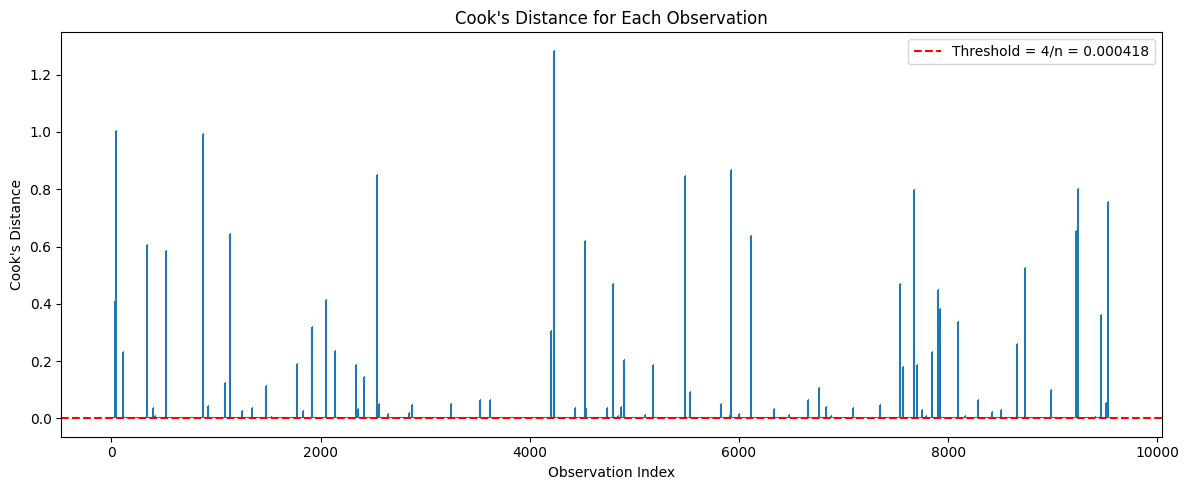

In [95]:
# Visualize Cook's Distance
plt.figure(figsize=(12, 5))
plt.stem(range(n), cooks_d, markerfmt=',', basefmt=' ')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = 4/n = {threshold:.6f}')
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Each Observation")
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
# Remove outliers and create clean DataFrame
df_clean = df[~outlier_mask].copy().reset_index(drop=True)

print(f"Original dataset size: {len(df)}")
print(f"Clean dataset size: {len(df_clean)}")
print(f"Removed {len(df) - len(df_clean)} outliers")

Original dataset size: 9568
Clean dataset size: 9448
Removed 120 outliers


In [97]:
# Export clean dataset to usina.csv
df_clean.to_csv("data/usina.csv", index=False)
print("Clean dataset exported to: data/usina.csv")

Clean dataset exported to: data/usina.csv


In [98]:
# Verify export
df_verify = pd.read_csv("data/usina.csv")
print("Verified clean dataset shape:", df_verify.shape)
display(df_verify.head())

Verified clean dataset shape: (9448, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


---
# Q2: Train/Test Evaluation Before vs After Outlier Removal

Compare model performance on:
- usina_with_outliers.csv (with outliers)
- usina.csv (after removing outliers)

Models: Linear Regression, Ridge Regression, Lasso Regression

Constraint: Do NOT scale features or target

Metrics: MAE, MSE, R2

Lambda values for Ridge/Lasso: {0.01, 0.1, 1, 10, 100}

In [99]:
# Helper function to compute metrics
def eval_metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def train_and_evaluate_models(X_train, X_test, y_train, y_test, lambda_values):
    results = []
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    train_metrics = eval_metrics(y_train, lr.predict(X_train))
    test_metrics = eval_metrics(y_test, lr.predict(X_test))
    results.append({
        "Model": "Linear Regression",
        "Train MSE": train_metrics["MSE"],
        "Train MAE": train_metrics["MAE"],
        "Train R2": train_metrics["R2"],
        "Test MSE": test_metrics["MSE"],
        "Test MAE": test_metrics["MAE"],
        "Test R2": test_metrics["R2"],
    })
    
    # Ridge Regression
    for lam in lambda_values:
        ridge = Ridge(alpha=lam, random_state=42)
        ridge.fit(X_train, y_train)
        train_metrics = eval_metrics(y_train, ridge.predict(X_train))
        test_metrics = eval_metrics(y_test, ridge.predict(X_test))
        results.append({
            "Model": f"Ridge (λ={lam})",
            "Train MSE": train_metrics["MSE"],
            "Train MAE": train_metrics["MAE"],
            "Train R2": train_metrics["R2"],
            "Test MSE": test_metrics["MSE"],
            "Test MAE": test_metrics["MAE"],
            "Test R2": test_metrics["R2"],
        })
    
    # Lasso Regression
    for lam in lambda_values:
        lasso = Lasso(alpha=lam, max_iter=10000, random_state=42)
        lasso.fit(X_train, y_train)
        train_metrics = eval_metrics(y_train, lasso.predict(X_train))
        test_metrics = eval_metrics(y_test, lasso.predict(X_test))
        results.append({
            "Model": f"Lasso (λ={lam})",
            "Train MSE": train_metrics["MSE"],
            "Train MAE": train_metrics["MAE"],
            "Train R2": train_metrics["R2"],
            "Test MSE": test_metrics["MSE"],
            "Test MAE": test_metrics["MAE"],
            "Test R2": test_metrics["R2"],
        })
    
    return pd.DataFrame(results)

lambda_values = [0.01, 0.1, 1, 10, 100]
print("Helper functions defined.")

Helper functions defined.


---
## Q2.1 — Train on `usina_with_outliers.csv` (with outliers)

In [100]:
# Load data WITH outliers
df_outliers = pd.read_csv("data/usina_with_outliers.csv")

feature_cols = ['AT', 'V', 'AP', 'RH']
target_col = 'PE'

X_out = df_outliers[feature_cols].values
y_out = df_outliers[target_col].values

# Split into train (70%) and test (30%)
X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_out, y_out, test_size=0.30, random_state=42
)

print("Data WITH outliers:")
print(f"  Total samples: {len(df_outliers)}")
print(f"  Train samples: {len(X_train_out)}")
print(f"  Test samples: {len(X_test_out)}")

Data WITH outliers:
  Total samples: 9568
  Train samples: 6697
  Test samples: 2871


In [101]:
# Train and evaluate models on data WITH outliers
results_with_outliers = train_and_evaluate_models(
    X_train_out, X_test_out, y_train_out, y_test_out, lambda_values
)

print("Results on usina_with_outliers.csv (WITH outliers):")
display(results_with_outliers)

Results on usina_with_outliers.csv (WITH outliers):


,Model,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,Linear Regression,123.384207,5.198679,0.650171,125.113389,5.052458,0.642574
1,Ridge (λ=0.01),123.384207,5.198679,0.650171,125.113389,5.052458,0.642574
2,Ridge (λ=0.1),123.384207,5.198680,0.650171,125.113392,5.052459,0.642574
3,Ridge (λ=1),123.384207,5.198685,0.650171,125.113421,5.052463,0.642574
4,Ridge (λ=10),123.384207,5.198737,0.650171,125.113705,5.052513,0.642573
5,Ridge (λ=100),123.384213,5.199261,0.650171,125.116548,5.053003,0.642565
6,Lasso (λ=0.01),123.384210,5.198858,0.650171,125.115332,5.052626,0.642568
7,Lasso (λ=0.1),123.384607,5.201739,0.650169,125.134495,5.055348,0.642514
8,Lasso (λ=1),123.421151,5.229507,0.650066,125.338356,5.083092,0.641931
9,Lasso (λ=10),126.141514,5.540418,0.642353,128.902136,5.408803,0.631750


---
## Q2.2 — Train on `usina.csv` (without outliers)

In [102]:
# Load data WITHOUT outliers
df_clean = pd.read_csv("data/usina.csv")

X_clean = df_clean[feature_cols].values
y_clean = df_clean[target_col].values

# Split into train (70%) and test (30%)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.30, random_state=42
)

print("Data WITHOUT outliers:")
print(f"  Total samples: {len(df_clean)}")
print(f"  Train samples: {len(X_train_clean)}")
print(f"  Test samples: {len(X_test_clean)}")

Data WITHOUT outliers:
  Total samples: 9448
  Train samples: 6613
  Test samples: 2835


In [103]:
# Train and evaluate models on data WITHOUT outliers
results_without_outliers = train_and_evaluate_models(
    X_train_clean, X_test_clean, y_train_clean, y_test_clean, lambda_values
)

print("Results on usina.csv (WITHOUT outliers):")
display(results_without_outliers)

Results on usina.csv (WITHOUT outliers):


,Model,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,Linear Regression,19.864671,3.596396,0.931369,20.396772,3.624773,0.930302
1,Ridge (λ=0.01),19.864671,3.596396,0.931369,20.396772,3.624773,0.930302
2,Ridge (λ=0.1),19.864671,3.596397,0.931369,20.396770,3.624773,0.930302
3,Ridge (λ=1),19.864671,3.596400,0.931369,20.396750,3.624774,0.930302
4,Ridge (λ=10),19.864672,3.596430,0.931369,20.396549,3.624783,0.930303
5,Ridge (λ=100),19.864758,3.596742,0.931369,20.394626,3.624880,0.930310
6,Lasso (λ=0.01),19.864675,3.596368,0.931369,20.396738,3.624754,0.930302
7,Lasso (λ=0.1),19.865263,3.596855,0.931367,20.392600,3.624890,0.930316
8,Lasso (λ=1),19.929852,3.605523,0.931144,20.414755,3.631153,0.930241
9,Lasso (λ=10),25.685683,4.086632,0.911258,26.157253,4.120464,0.910618


---
## Q2 — Side-by-Side Comparison

In [104]:
# Side-by-side comparison
print("=" * 70)
print("COMPARISON: WITH OUTLIERS vs WITHOUT OUTLIERS")
print("=" * 70)

print("\nWITH OUTLIERS (usina_with_outliers.csv):")
display(results_with_outliers)

print("\nWITHOUT OUTLIERS (usina.csv):")
display(results_without_outliers)

COMPARISON: WITH OUTLIERS vs WITHOUT OUTLIERS

WITH OUTLIERS (usina_with_outliers.csv):


,Model,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,Linear Regression,123.384207,5.198679,0.650171,125.113389,5.052458,0.642574
1,Ridge (λ=0.01),123.384207,5.198679,0.650171,125.113389,5.052458,0.642574
2,Ridge (λ=0.1),123.384207,5.198680,0.650171,125.113392,5.052459,0.642574
3,Ridge (λ=1),123.384207,5.198685,0.650171,125.113421,5.052463,0.642574
4,Ridge (λ=10),123.384207,5.198737,0.650171,125.113705,5.052513,0.642573
5,Ridge (λ=100),123.384213,5.199261,0.650171,125.116548,5.053003,0.642565
6,Lasso (λ=0.01),123.384210,5.198858,0.650171,125.115332,5.052626,0.642568
7,Lasso (λ=0.1),123.384607,5.201739,0.650169,125.134495,5.055348,0.642514
8,Lasso (λ=1),123.421151,5.229507,0.650066,125.338356,5.083092,0.641931
9,Lasso (λ=10),126.141514,5.540418,0.642353,128.902136,5.408803,0.631750



WITHOUT OUTLIERS (usina.csv):


,Model,Train MSE,Train MAE,Train R2,Test MSE,Test MAE,Test R2
0,Linear Regression,19.864671,3.596396,0.931369,20.396772,3.624773,0.930302
1,Ridge (λ=0.01),19.864671,3.596396,0.931369,20.396772,3.624773,0.930302
2,Ridge (λ=0.1),19.864671,3.596397,0.931369,20.396770,3.624773,0.930302
3,Ridge (λ=1),19.864671,3.596400,0.931369,20.396750,3.624774,0.930302
4,Ridge (λ=10),19.864672,3.596430,0.931369,20.396549,3.624783,0.930303
5,Ridge (λ=100),19.864758,3.596742,0.931369,20.394626,3.624880,0.930310
6,Lasso (λ=0.01),19.864675,3.596368,0.931369,20.396738,3.624754,0.930302
7,Lasso (λ=0.1),19.865263,3.596855,0.931367,20.392600,3.624890,0.930316
8,Lasso (λ=1),19.929852,3.605523,0.931144,20.414755,3.631153,0.930241
9,Lasso (λ=10),25.685683,4.086632,0.911258,26.157253,4.120464,0.910618


## Q2 — Discussion

### Do outliers change train error? Test error?

Yes, dramatically. Removing outliers reduces error by about 6x:

| Dataset | Train MSE | Test MSE | Train R² | Test R² |
|---------|-----------|----------|----------|---------|
| With outliers | 123.38 | 125.11 | 0.650 | 0.643 |
| Without outliers | 19.86 | 20.40 | 0.931 | 0.930 |

The outliers inflate both train and test error because they distort the regression coefficients.

### Which dataset shows better generalization?

The dataset without outliers generalizes better. Both datasets show small train-test gaps (no overfitting), but the clean dataset achieves R2 around 0.93 compared to only 0.65 with outliers. The MSE drops from ~125 to ~20.

### Do Ridge/Lasso help relative to Linear Regression?

No. Ridge performs nearly identically to Linear Regression across all λ values. Lasso matches Linear for small λ but degrades at larger λ (10, 100) as it shrinks coefficients too aggressively.

The problem here is data quality, not overfitting. Regularization cannot fix corrupted data — only removing outliers helps.

---
# Q3: Reliability of Coefficients (Outlier-Removed Dataset)

Dataset: usina.csv (clean, outlier-removed)

Task: Identify the most/least reliable coefficients.

---

## Q3.1 — Method Choice and Scaling Decision

Model: Linear Regression (OLS)
- Reliability is measured by t-statistics
- T-statistics are defined for OLS, not for regularized models
- Ridge/Lasso bias the coefficient estimates, making t-statistics invalid

Library: Statsmodels OLS
- Provides t-statistics and p-values directly

Scaling: Do NOT scale IVs or DV
- T-statistics are scale-invariant: if you scale a feature by constant c, both the coefficient and its standard error scale by 1/c, so t = coef/SE remains unchanged
- Therefore scaling provides no benefit for reliability analysis
- Keeping original units also makes coefficient interpretation easier

Interpretation:
- Higher |t-statistic| = more reliable
- Lower p-value = more reliable

---
## Q3.2 — Implementation and Results

In [105]:
# Load clean dataset
df_q3 = pd.read_csv("data/usina.csv")

feature_cols = ['AT', 'V', 'AP', 'RH']
target_col = 'PE'

X_q3 = df_q3[feature_cols].values
y_q3 = df_q3[target_col].values

# Split into train (70%) and test (30%)
X_train_q3, X_test_q3, y_train_q3, y_test_q3 = train_test_split(
    X_q3, y_q3, test_size=0.30, random_state=42
)

print("Q3 Data (clean, outlier-removed):")
print(f"  Total samples: {len(df_q3)}")
print(f"  Train samples: {len(X_train_q3)}")
print(f"  Test samples: {len(X_test_q3)}")

Q3 Data (clean, outlier-removed):
  Total samples: 9448
  Train samples: 6613
  Test samples: 2835


In [106]:
# Fit OLS model using statsmodels
X_train_const = sm.add_constant(X_train_q3)
X_test_const = sm.add_constant(X_test_q3)

ols_q3 = sm.OLS(y_train_q3, X_train_const).fit()

print("OLS Regression Results:")
print(ols_q3.summary())

OLS Regression Results:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                 2.242e+04
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        12:30:44   Log-Likelihood:                -19266.
No. Observations:                6613   AIC:                         3.854e+04
Df Residuals:                    6608   BIC:                         3.858e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        443.7534     11

In [107]:
# Extract coefficient reliability information
coef_names = ['const', 'AT', 'V', 'AP', 'RH']

coef_df = pd.DataFrame({
    'Feature': coef_names,
    'Coefficient': ols_q3.params,
    'Std Error': ols_q3.bse,
    't-statistic': ols_q3.tvalues,
    'p-value': ols_q3.pvalues,
    '|t-statistic|': np.abs(ols_q3.tvalues)
})

# Sort by |t-statistic| descending (most reliable first)
coef_df_sorted = coef_df.sort_values('|t-statistic|', ascending=False)

print("Coefficient Reliability (sorted by |t-statistic|):")
display(coef_df_sorted)

Coefficient Reliability (sorted by |t-statistic|):


,Feature,Coefficient,Std Error,t-statistic,p-value,|t-statistic|
1,AT,-1.966193,0.018043,-108.971834,0.000000e+00,108.971834
0,const,443.753358,11.539335,38.455715,3.717392e-292,38.455715
4,RH,-0.150944,0.004832,-31.237663,6.360165e-200,31.237663
2,V,-0.234557,0.008563,-27.390969,1.487453e-156,27.390969
3,AP,0.072105,0.011200,6.438038,1.295207e-10,6.438038


In [108]:
# Identify most and least reliable coefficients (excluding intercept)
feature_coef_df = coef_df[coef_df['Feature'] != 'const'].copy()
feature_coef_df_sorted = feature_coef_df.sort_values('|t-statistic|', ascending=False)

most_reliable = feature_coef_df_sorted.iloc[0]
least_reliable = feature_coef_df_sorted.iloc[-1]

print("RELIABILITY RESULTS")
print("-" * 50)
print(f"\nMost Reliable: {most_reliable['Feature']}")
print(f"  Coefficient: {most_reliable['Coefficient']:.6f}")
print(f"  t-statistic: {most_reliable['t-statistic']:.4f}")
print(f"  p-value: {most_reliable['p-value']:.2e}")

print(f"\nLeast Reliable: {least_reliable['Feature']}")
print(f"  Coefficient: {least_reliable['Coefficient']:.6f}")
print(f"  t-statistic: {least_reliable['t-statistic']:.4f}")
print(f"  p-value: {least_reliable['p-value']:.2e}")

RELIABILITY RESULTS
--------------------------------------------------

Most Reliable: AT
  Coefficient: -1.966193
  t-statistic: -108.9718
  p-value: 0.00e+00

Least Reliable: AP
  Coefficient: 0.072105
  t-statistic: 6.4380
  p-value: 1.30e-10


In [109]:
# Report train/test metrics
y_pred_train = ols_q3.predict(X_train_const)
y_pred_test = ols_q3.predict(X_test_const)

train_metrics_q3 = eval_metrics(y_train_q3, y_pred_train)
test_metrics_q3 = eval_metrics(y_test_q3, y_pred_test)

print("Q3 Model Performance:")
print(f"  Train - MSE: {train_metrics_q3['MSE']:.4f}, MAE: {train_metrics_q3['MAE']:.4f}, R²: {train_metrics_q3['R2']:.4f}")
print(f"  Test  - MSE: {test_metrics_q3['MSE']:.4f}, MAE: {test_metrics_q3['MAE']:.4f}, R²: {test_metrics_q3['R2']:.4f}")

Q3 Model Performance:
  Train - MSE: 19.8647, MAE: 3.5964, R²: 0.9314
  Test  - MSE: 20.3968, MAE: 3.6248, R²: 0.9303


## Q3 — Conclusion

Based on OLS t-statistics (excluding intercept):

| Feature | Coefficient | t-statistic | p-value | Reliability Rank |
|---------|-------------|-------------|---------|------------------|
| AT | -1.966 | -108.97 | ~0 | 1st (Most Reliable) |
| RH | -0.151 | -31.24 | 6.36e-200 | 2nd |
| V | -0.235 | -27.39 | 1.49e-156 | 3rd |
| AP | 0.072 | 6.44 | 1.30e-10 | 4th (Least Reliable) |

Most Reliable: AT — highest |t-statistic| (108.97), p-value essentially zero.

Least Reliable: AP — lowest |t-statistic| (6.44), though still significant (p = 1.30e-10). All features have strong evidence of non-zero effects; AP is just the least certain among them.

---
# Q4: Most Important vs Least Important Features (Outlier-Removed Dataset)

Dataset: usina.csv (clean, outlier-removed)

Task: Identify most/least important features based on effect size (standardized coefficients).

Key Distinction from Q3:
- Q3 (Reliability): t-statistics measure certainty that coefficient is not 0
- Q4 (Importance): Standardized coefficients measure effect size

---

## Q4.1 — Method Choice and Scaling Decision

Model: Linear Regression
- Standardized coefficients measure relative effect size
- Ridge/Lasso shrink coefficients, distorting the true importance ranking
- OLS provides unbiased estimates for fair comparison

Library: scikit-learn
- Simpler workflow for scaling + regression

Scaling: YES — Scale BOTH IVs (X) and DV (y)
- Without scaling, coefficients have different units and are not comparable
- After standardizing, all coefficients are unitless
- Coefficient represents: how many SDs does y change when x increases by 1 SD

Interpretation:
- Higher |standardized coefficient| = more important
- Lower |standardized coefficient| = less important

---
## Q4.2 — Implementation and Results

In [110]:
# Load clean dataset
df_q4 = pd.read_csv("data/usina.csv")

feature_cols = ['AT', 'V', 'AP', 'RH']
target_col = 'PE'

X_q4 = df_q4[feature_cols].values
y_q4 = df_q4[target_col].values.reshape(-1, 1)

# Split into train (70%) and test (30%)
X_train_q4, X_test_q4, y_train_q4, y_test_q4 = train_test_split(
    X_q4, y_q4, test_size=0.30, random_state=42
)

print("Q4 Data:")
print(f"  Total samples: {len(df_q4)}")
print(f"  Train samples: {len(X_train_q4)}")
print(f"  Test samples: {len(X_test_q4)}")

Q4 Data:
  Total samples: 9448
  Train samples: 6613
  Test samples: 2835


In [111]:
# Standardize both X and y using training statistics
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train_q4)
X_test_scaled = x_scaler.transform(X_test_q4)

y_train_scaled = y_scaler.fit_transform(y_train_q4)
y_test_scaled = y_scaler.transform(y_test_q4)

print("Scaling applied:")
print(f"  X_train scaled mean: {X_train_scaled.mean(axis=0).round(6)}")
print(f"  X_train scaled std: {X_train_scaled.std(axis=0).round(6)}")

Scaling applied:
  X_train scaled mean: [ 0.  0.  0. -0.]
  X_train scaled std: [1. 1. 1. 1.]


In [112]:
# Fit Linear Regression on scaled data
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train_scaled.ravel())

standardized_coefs = lr_scaled.coef_

print("Linear Regression fitted on standardized data.")
print(f"Intercept: {lr_scaled.intercept_:.6f}")

Linear Regression fitted on standardized data.
Intercept: 0.000000


In [113]:
# Create importance table
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Standardized Coefficient': standardized_coefs,
    '|Standardized Coefficient|': np.abs(standardized_coefs)
})

importance_df_sorted = importance_df.sort_values('|Standardized Coefficient|', ascending=False)

print("Feature Importance (Standardized Coefficients):")
display(importance_df_sorted)

Feature Importance (Standardized Coefficients):


,Feature,Standardized Coefficient,|Standardized Coefficient|
0,AT,-0.860352,0.860352
1,V,-0.175103,0.175103
3,RH,-0.131132,0.131132
2,AP,0.025179,0.025179


In [114]:
# Identify most and least important features
most_important = importance_df_sorted.iloc[0]
least_important = importance_df_sorted.iloc[-1]

print("IMPORTANCE RESULTS")
print("-" * 50)
print(f"\nMost Important: {most_important['Feature']}")
print(f"  Standardized Coefficient: {most_important['Standardized Coefficient']:.6f}")
print(f"  1 SD increase in {most_important['Feature']} → {most_important['Standardized Coefficient']:.4f} SD change in PE")

print(f"\nLeast Important: {least_important['Feature']}")
print(f"  Standardized Coefficient: {least_important['Standardized Coefficient']:.6f}")
print(f"  1 SD increase in {least_important['Feature']} → {least_important['Standardized Coefficient']:.4f} SD change in PE")

IMPORTANCE RESULTS
--------------------------------------------------

Most Important: AT
  Standardized Coefficient: -0.860352
  1 SD increase in AT → -0.8604 SD change in PE

Least Important: AP
  Standardized Coefficient: 0.025179
  1 SD increase in AP → 0.0252 SD change in PE


In [115]:
# Report train/test metrics (in original units)
y_pred_train_scaled = lr_scaled.predict(X_train_scaled).reshape(-1, 1)
y_pred_test_scaled = lr_scaled.predict(X_test_scaled).reshape(-1, 1)

y_pred_train_orig = y_scaler.inverse_transform(y_pred_train_scaled)
y_pred_test_orig = y_scaler.inverse_transform(y_pred_test_scaled)

train_metrics_q4 = eval_metrics(y_train_q4.ravel(), y_pred_train_orig.ravel())
test_metrics_q4 = eval_metrics(y_test_q4.ravel(), y_pred_test_orig.ravel())

print("Q4 Model Performance:")
print(f"  Train - MSE: {train_metrics_q4['MSE']:.4f}, MAE: {train_metrics_q4['MAE']:.4f}, R²: {train_metrics_q4['R2']:.4f}")
print(f"  Test  - MSE: {test_metrics_q4['MSE']:.4f}, MAE: {test_metrics_q4['MAE']:.4f}, R²: {test_metrics_q4['R2']:.4f}")

Q4 Model Performance:
  Train - MSE: 19.8647, MAE: 3.5964, R²: 0.9314
  Test  - MSE: 20.3968, MAE: 3.6248, R²: 0.9303


## Q4 — Conclusion

Based on standardized coefficients (effect size):

| Feature | Std Coefficient | Abs Value | Importance Rank |
|---------|-----------------|-----------|-----------------|
| AT | -0.860 | 0.860 | 1st (Most Important) |
| V | -0.175 | 0.175 | 2nd |
| RH | -0.131 | 0.131 | 3rd |
| AP | 0.025 | 0.025 | 4th (Least Important) |

Most Important: AT — standardized coefficient of -0.860 means a 1 SD increase in AT causes a 0.86 SD decrease in power output. AT has the strongest effect (about 5x larger than V).

Least Important: AP — standardized coefficient of 0.025 means a 1 SD increase in AP causes only a 0.025 SD increase in power output. Very weak effect.

### Q3 vs Q4 Comparison

| Question | Measures | Scaling | Most | Least |
|----------|----------|---------|------|-------|
| Q3 (Reliability) | t-statistics | No | AT | AP |
| Q4 (Importance) | Std Coef | Yes | AT | AP |

Both questions identify the same features: AT is the most reliable and most important, while AP is the least reliable and least important.

---
# Q5: Regularization Paths (Scaled Data, Outlier-Removed Dataset)

Dataset: usina.csv (clean, outlier-removed)

Constraints:
- Scale IVs (required)
- Scaling DV is optional (we will not scale y)
- Vary lambda over a reasonable range (100 log-spaced values)

Goal: Visualize how Ridge and Lasso coefficients change as lambda increases.

## Q5.1 & Q5.2 — Setup and Generate λ Values

In [116]:
# Load and prepare data
df_q5 = pd.read_csv("data/usina.csv")

feature_cols = ['AT', 'V', 'AP', 'RH']
target_col = 'PE'

X_q5 = df_q5[feature_cols].values
y_q5 = df_q5[target_col].values

# Split into train (70%) and test (30%)
X_train_q5, X_test_q5, y_train_q5, y_test_q5 = train_test_split(
    X_q5, y_q5, test_size=0.30, random_state=42
)

# Scale X only
x_scaler_q5 = StandardScaler()
X_train_scaled_q5 = x_scaler_q5.fit_transform(X_train_q5)
X_test_scaled_q5 = x_scaler_q5.transform(X_test_q5)

print("Q5 Data prepared:")
print(f"  Train samples: {len(X_train_q5)}")
print(f"  Test samples: {len(X_test_q5)}")
print(f"  X scaled: Yes, y scaled: No")

Q5 Data prepared:
  Train samples: 6613
  Test samples: 2835
  X scaled: Yes, y scaled: No


In [117]:
# Generate 100 log-spaced λ values
lambdas = np.logspace(-2, 4, 100)

print(f"Generated {len(lambdas)} λ values (log-spaced)")
print(f"  Min λ: {lambdas.min():.4f}")
print(f"  Max λ: {lambdas.max():.4f}")

Generated 100 λ values (log-spaced)
  Min λ: 0.0100
  Max λ: 10000.0000


## Q5.3 — Fit Models and Record Coefficients

In [118]:
# Fit Ridge and Lasso for each λ, record coefficients
ridge_coefs = []
lasso_coefs = []

for lam in lambdas:
    ridge = Ridge(alpha=lam, random_state=42)
    ridge.fit(X_train_scaled_q5, y_train_q5)
    ridge_coefs.append(ridge.coef_)
    
    lasso = Lasso(alpha=lam, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled_q5, y_train_q5)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

print(f"Ridge coefficients shape: {ridge_coefs.shape}")
print(f"Lasso coefficients shape: {lasso_coefs.shape}")

Ridge coefficients shape: (100, 4)
Lasso coefficients shape: (100, 4)


## Q5.4 — Plot Coefficient Paths

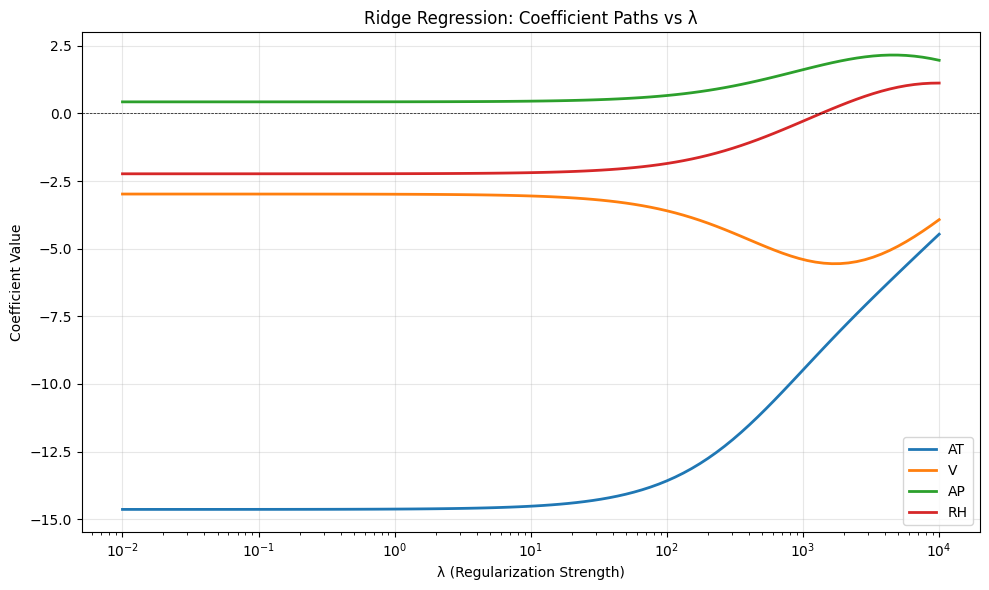

In [119]:
# Plot Ridge Regularization Path
plt.figure(figsize=(10, 6))

for i, feature in enumerate(feature_cols):
    plt.plot(lambdas, ridge_coefs[:, i], label=feature, linewidth=2)

plt.xscale('log')
plt.xlabel('λ (Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Paths vs λ')
plt.legend(loc='best')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

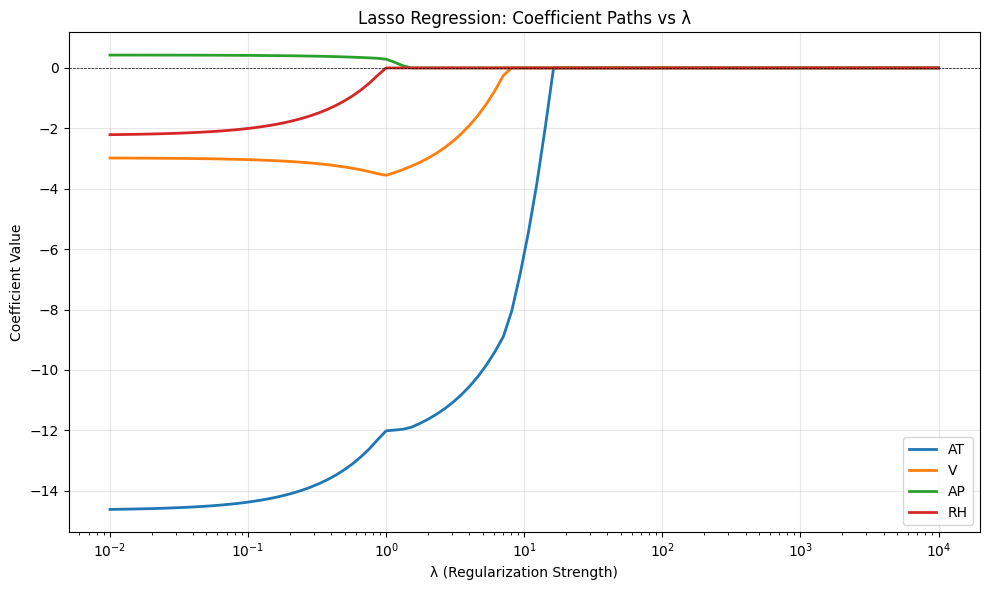

In [120]:
# Plot Lasso Regularization Path
plt.figure(figsize=(10, 6))

for i, feature in enumerate(feature_cols):
    plt.plot(lambdas, lasso_coefs[:, i], label=feature, linewidth=2)

plt.xscale('log')
plt.xlabel('λ (Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression: Coefficient Paths vs λ')
plt.legend(loc='best')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q5 — Discussion

### What happens to coefficients as lambda increases in Ridge vs Lasso?

Ridge: Coefficients shrink smoothly toward zero but never become exactly zero. All 4 features retain non-zero coefficients even at very high lambda. See Ridge plot — AT shrinks from ~-14 toward 0, but never reaches it.

Lasso: Coefficients shrink and can become exactly zero. AP (least important) reaches zero first, then RH and V, and AT is the last to shrink. This creates sparse models. See Lasso plot — at lambda around 10, only AT has a non-zero coefficient.

### Which regression is better under multicollinearity?

Ridge is better. When features are correlated, Ridge distributes weight across them rather than arbitrarily picking one. The L2 penalty shrinks all coefficients proportionally, stabilizing estimates. In the Ridge plot, all 4 features maintain non-zero coefficients across all lambda values.

### Which regression is better for feature selection?

Lasso is better. Its L1 penalty produces sparse solutions where coefficients become exactly zero. As lambda increases, features drop out sequentially (AP first, then RH, then V, then AT) — this matches the importance ranking from Q4. Ridge cannot do feature selection because all coefficients remain non-zero.